**Goal:** Run the full EDA workflow -- clean, explore each variable, explore
relationships, synthesize findings -- on a dataset you haven't seen before.
This is Unit III's capstone: everything from L07 and L08, applied end-to-end.

> This page is the read-only view. To run the lab, open
> `l09_lab_eda_mini_project.ipynb` locally or in Colab.

## The Problem

What factors drive house prices? Real estate is the largest financial asset most
families own. In Puerto Rico, the housing market saw sharp post-Maria contractions
and uneven rebounds by municipality -- headline averages masked wildly different
local stories. A full EDA is exactly the tool that separates those stories.

Today's dataset: **Ames Housing** -- 1,460 residential property sales in Ames,
Iowa (2006-2010), De Cock 2011, *Journal of Statistics Education*. We work with
12 carefully chosen columns that give us a mix of numeric and categorical
variables, real missing values, and a clear target (`SalePrice`).

> **Where this sits:** builds on L07 (univariate EDA) and L08 (bivariate/correlation)
> -- Unit III capstone -- prepares for Unit IV (data mining and feature engineering).

## Learning Objectives

By the end of this lab you will be able to:

- **Apply** a complete EDA workflow (clean -> univariate -> bivariate -> report) to
  an unfamiliar dataset
- **Identify and handle** missing values using appropriate strategies
  (median/mode impute vs. drop)
- **Classify** variables by type (discrete, continuous, nominal, ordinal) and
  choose the right plot for each
- **Synthesize** univariate and bivariate findings into a written data story

## Prerequisites & Setup

Run this cell first. It downloads the Ames Housing data from OpenML (one-time,
~1 MB), subsets to 12 columns, and caches the result as `data/ames_subset.csv`
so subsequent runs are instant.

The dataset is from the Kaggle "House Prices" competition
(De Cock 2011, *JSE*; CC BY-NC-SA 4.0 -- educational use permitted).

In [1]:
# Setup: run this cell first (required for Colab -- it resets on open)
%pip install -q scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

CACHE = "data/ames_subset.csv"
COLS  = ["SalePrice", "GrLivArea", "LotArea", "YearBuilt", "OverallQual",
         "BedroomAbvGr", "FullBath", "GarageArea", "Neighborhood",
         "HouseStyle", "LotFrontage", "MasVnrArea"]

if os.path.exists(CACHE):
    df = pd.read_csv(CACHE)
else:
    from sklearn.datasets import fetch_openml
    raw = fetch_openml("house_prices", version=1, as_frame=True, parser="auto")
    df = raw.frame[COLS].copy()
    os.makedirs("data", exist_ok=True)
    df.to_csv(CACHE, index=False)

print(df.shape)
df.head(3)

(1460, 12)


,SalePrice,GrLivArea,LotArea,YearBuilt,OverallQual,BedroomAbvGr,FullBath,GarageArea,Neighborhood,HouseStyle,LotFrontage,MasVnrArea
0,208500,1710,8450,2003,7,3,2,548,CollgCr,2Story,65.0,196.0
1,181500,1262,9600,1976,6,3,2,460,Veenker,1Story,80.0,0.0
2,223500,1786,11250,2001,7,3,2,608,CollgCr,2Story,68.0,162.0


<details><summary>Expected Output</summary>

~~~text
(1460, 12)
~~~
*(...followed by the first three rows: house IDs 1-3, a 2Story in CollgCr, a
1Story in Veenker, and a 2Story in CollgCr, with their features.)*
</details>

---

## Step 1: First Look -- Structure, Quality, and the Headline Numbers (Worked)

Every EDA starts the same way: *what is here*, *what is broken*, and *what are the
headline numbers*. We answered these questions with penguins in L07; now do it
on a dataset you haven't seen before.

### 1a. Structure and data types

In [3]:
print(df.dtypes)

SalePrice         int64
GrLivArea         int64
LotArea           int64
YearBuilt         int64
OverallQual       int64
BedroomAbvGr      int64
FullBath          int64
GarageArea        int64
Neighborhood     object
HouseStyle       object
LotFrontage     float64
MasVnrArea      float64
dtype: object


<details><summary>Expected Output</summary>

~~~text
SalePrice         int64
GrLivArea         int64
LotArea           int64
YearBuilt         int64
OverallQual       int64
BedroomAbvGr      int64
FullBath          int64
GarageArea        int64
Neighborhood     object
HouseStyle       object
LotFrontage     float64
MasVnrArea      float64
dtype: object
~~~
</details>

> **Feature type taxonomy** -- before plotting anything, classify each column:
>
> | Type | Meaning | Columns here |
> |------|---------|--------------|
> | Numerical -- continuous | any real value in a range | SalePrice, GrLivArea, LotArea, GarageArea, LotFrontage, MasVnrArea |
> | Numerical -- discrete | integer-valued; not a ratio or count, but takes only whole-number values | YearBuilt, BedroomAbvGr, FullBath |
> | Categorical -- ordinal | categories with a meaningful order | OverallQual (1=poor to 10=excellent) |
> | Categorical -- nominal | categories with no natural order | Neighborhood, HouseStyle |
>
> The type tells you which plot to reach for: histograms for continuous,
> bar charts for categorical. OverallQual looks numeric but it's ordinal --
> the gap between quality 3 and 4 is not the same as between 9 and 10.

**Completion -- classify these four columns:**

In [4]:
# TODO: fill in the type for each column.
# Choose from: Continuous / Discrete / Nominal / Ordinal

# MasVnrArea  (masonry veneer area in sq ft) -> ____
# Neighborhood (neighbourhood name)          -> ____
# OverallQual  (quality rating 1-10)         -> ____
# YearBuilt    (year of construction)        -> ____

<details><summary>Expected Answers</summary>

~~~text
MasVnrArea  -> Continuous  (any non-negative real value; fractions of a sq ft possible)
Neighborhood -> Nominal    (named places; no ordering implied)
OverallQual  -> Ordinal    (1-10 with meaningful order; gaps unequal)
YearBuilt    -> Discrete   (integer years; not a count; ordered)
~~~
</details>

### 1b. Missing values and duplicates

In [5]:
print(df.isnull().sum().sort_values(ascending=False))
print()
print("Duplicate rows:", df.duplicated().sum())

LotFrontage     259
MasVnrArea        8
SalePrice         0
GrLivArea         0
LotArea           0
YearBuilt         0
OverallQual       0
BedroomAbvGr      0
FullBath          0
GarageArea        0
Neighborhood      0
HouseStyle        0
dtype: int64

Duplicate rows: 0


<details><summary>Expected Output</summary>

~~~text
LotFrontage     259
MasVnrArea        8
SalePrice         0
GrLivArea         0
LotArea           0
YearBuilt         0
OverallQual       0
BedroomAbvGr      0
FullBath          0
GarageArea        0
Neighborhood      0
HouseStyle        0
dtype: int64

Duplicate rows: 0
~~~
</details>

> **Read it:** Two columns have missing values. LotFrontage -- the feet of street
> frontage a lot has -- is missing for 259 of 1,460 houses (~18%). MasVnrArea
> (masonry veneer area) is missing for just 8. No duplicate rows.
>
> Before touching those NaNs, ask: *why* are they missing? That question matters
> more than the count -- see the Appendix for the MCAR/MAR/MNAR taxonomy.

### 1c. Headline numbers

In [6]:
print(df["SalePrice"].describe())
print(f"\nmean / median ratio: {df['SalePrice'].mean() / df['SalePrice'].median():.2f}")

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

mean / median ratio: 1.11


<details><summary>Expected Output</summary>

~~~text
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

mean / median ratio: 1.11
~~~
</details>

> **Read it:** The mean ($181k) sits above the median ($163k) -- a sign of
> right-skew: a tail of expensive homes pulls the average up. The middle 50%
> of sales fall between $130k and $214k.

---

## Step 2: Data Cleaning -- Impute, Don't Drop (Worked)

We have two columns with missing values. The naive fix is `dropna()`. Let's see
what that costs.

In [7]:
print(f"Shape before cleaning:          {df.shape}")
print(f"Shape after dropna():           {df.dropna().shape}")
print(f"Rows lost:                      {len(df) - len(df.dropna())}  ({(len(df)-len(df.dropna()))/len(df)*100:.0f}%)")

Shape before cleaning:          (1460, 12)
Shape after dropna():           (1195, 12)
Rows lost:                      265  (18%)


<details><summary>Expected Output</summary>

~~~text
Shape before cleaning:          (1460, 12)
Shape after dropna():           (1195, 12)
Rows lost:                      265  (18%)
~~~
</details>

> **Read it:** Dropping any row with a NaN throws away 18% of the data --
> almost all of it because of LotFrontage alone. Better strategy: targeted
> imputation.

In [8]:
# LotFrontage: fill with the median (69 ft) -- the safest numeric default
# MasVnrArea:  fill with 0 -- a valid value (no masonry veneer on that house)
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["MasVnrArea"]  = df["MasVnrArea"].fillna(0)

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Shape preserved:          {df.shape}")

Missing values remaining: 0
Shape preserved:          (1460, 12)


<details><summary>Expected Output</summary>

~~~text
Missing values remaining: 0
Shape preserved:          (1460, 12)
~~~
</details>

> **Why median, not mean?** SalePrice and LotFrontage are right-skewed -- the mean
> gets pulled by outliers. The median is a more robust center for skewed
> distributions. (We learned this in L07.)
>
> **Why 0 for MasVnrArea?** Zero is a legitimate value -- it means no veneer.
> Only 8 rows are affected; median-filling would give those 8 houses a typical
> veneer area they probably don't have.

### 2b. Type coercion -- knowing when to change types (Worked)

`dtypes` showed OverallQual as `int64`. We keep it numeric here so it can be
used in scatter plots and correlation calculations. But if you wanted to
communicate that the gaps between levels are unequal -- quality 8 is NOT twice
quality 4 -- you would convert to an ordered Categorical:

In [9]:
# Illustration -- we create a separate series so the main df is unchanged
qual_typed = pd.Categorical(
    df["OverallQual"],
    categories=sorted(df["OverallQual"].unique()),
    ordered=True
)
print(qual_typed.dtype)
print("ordered:", qual_typed.ordered)
print("categories:", list(qual_typed.categories))

category
ordered: True
categories: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


<details><summary>Expected Output</summary>

~~~text
category
ordered: True
categories: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
~~~
</details>

> **YearBuilt** stays `int64` -- we care about the numeric year value (1950 vs
> 2000), not time arithmetic like durations or seasons. Converting it to
> `datetime64` (a timestamp type) would complicate every calculation for no
> benefit here.

---

## Step 3: Univariate EDA -- Reading Each Variable (Worked + Completion)

### 3a. The target: SalePrice

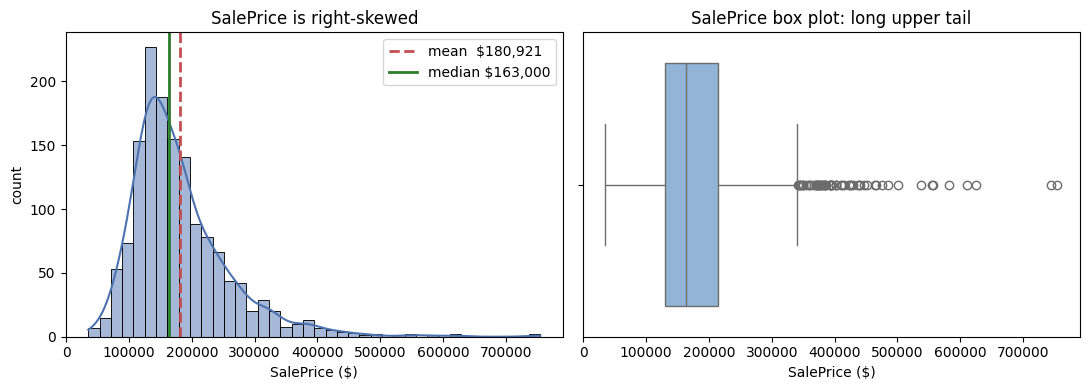

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: histogram + KDE
sns.histplot(df["SalePrice"], bins=40, kde=True, color="#4c72b0", ax=axes[0])
axes[0].axvline(df["SalePrice"].mean(),   color="#c44e52", linestyle="--",
                linewidth=2, label=f"mean  ${df['SalePrice'].mean():,.0f}")
axes[0].axvline(df["SalePrice"].median(), color="#2a7d2a", linestyle="-",
                linewidth=2, label=f"median ${df['SalePrice'].median():,.0f}")
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("count")
axes[0].set_title("SalePrice is right-skewed")
axes[0].legend()

# Right: box plot
sns.boxplot(x=df["SalePrice"], color="#86b4e3", ax=axes[1])
axes[1].set_xlabel("SalePrice ($)")
axes[1].set_title("SalePrice box plot: long upper tail")

fig.tight_layout()
plt.show()

> **Read it:** The histogram is right-skewed (skew = 1.88): most houses sell
> between $130k-$214k, but a handful top $500k. The mean ($181k) sits to the
> right of the median ($163k). The box plot confirms a long upper fence --
> roughly 61 data points sit beyond the upper whisker (the 1.5xIQR threshold
> is ~$340k; verified: `(df["SalePrice"] > 340038).sum()`).

### 3b. OverallQual -- the ordinal predictor

OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64


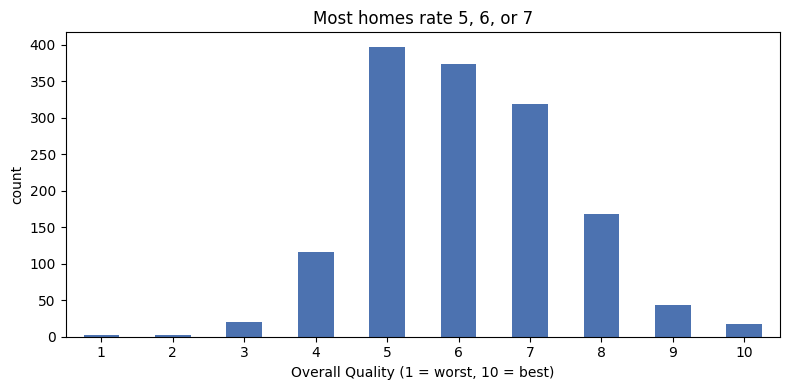

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df["OverallQual"].value_counts().sort_index()
print(counts)
counts.plot(kind="bar", color="#4c72b0", ax=ax)
ax.set_xlabel("Overall Quality (1 = worst, 10 = best)")
ax.set_ylabel("count")
ax.set_title("Most homes rate 5, 6, or 7")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

<details><summary>Expected Output (counts)</summary>

~~~text
OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64
~~~
</details>

> **Read it:** Quality follows a roughly normal-ish distribution centered on 5-6.
> Very few homes earn the top ratings (43 at 9, 18 at 10) -- those will drive
> the price extremes we saw in the SalePrice histogram.

### 3c. GrLivArea -- completion exercise

GrLivArea is above-ground living area in square feet -- one of the most important
numeric predictors (you will quantify exactly how important in Step 4). Plot its
histogram and KDE overlay, choose a bin count that reveals the shape clearly
(try values between 20 and 50), and write a one-sentence shape interpretation.

count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64
skew = 1.37


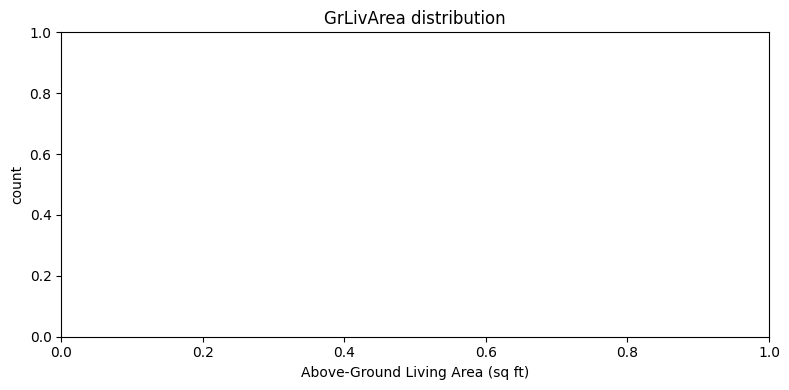

In [12]:
print(df["GrLivArea"].describe())
print(f"skew = {df['GrLivArea'].skew():.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
# TODO: uncomment and complete the two arguments below
# sns.histplot(df["GrLivArea"], bins=____, kde=____, color="#4c72b0", ax=ax)
ax.set_xlabel("Above-Ground Living Area (sq ft)")
ax.set_ylabel("count")
ax.set_title("GrLivArea distribution")
plt.tight_layout()
plt.show()

# TODO: write one sentence -- what shape is this distribution, and what does that
#       tell you about living areas in Ames?
# Shape interpretation: ____

<details><summary>Expected Output</summary>

~~~text
count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64
skew = 1.37
~~~
*Right-skewed (skew = 1.37): mean 1,515 sq ft > median 1,464 sq ft; a handful
of very large homes form the upper tail. The histogram should show most bars
between 1,000-2,000 sq ft with a long rightward tail up to ~5,600 sq ft.*
</details>

---

## Step 4: Bivariate EDA -- Reading Relationships (Worked + Completion)

### 4a. Correlation landscape (worked)

In [13]:
num_cols = df.select_dtypes("number").columns.tolist()
corr_sp  = df[num_cols].corr()["SalePrice"].sort_values(ascending=False)
print(corr_sp.round(2))

SalePrice       1.00
OverallQual     0.79
GrLivArea       0.71
GarageArea      0.62
FullBath        0.56
YearBuilt       0.52
MasVnrArea      0.47
LotFrontage     0.33
LotArea         0.26
BedroomAbvGr    0.17
Name: SalePrice, dtype: float64


<details><summary>Expected Output</summary>

~~~text
SalePrice       1.00
OverallQual     0.79
GrLivArea       0.71
GarageArea      0.62
FullBath        0.56
YearBuilt       0.52
MasVnrArea      0.47
LotFrontage     0.33
LotArea         0.26
BedroomAbvGr    0.17
Name: SalePrice, dtype: float64
~~~
</details>

> **Read it:** OverallQual (r = 0.79) and GrLivArea (r = 0.71) are the two
> strongest predictors. BedroomAbvGr has the weakest linear relationship (r =
> 0.17) -- more bedrooms does not reliably mean a higher price.

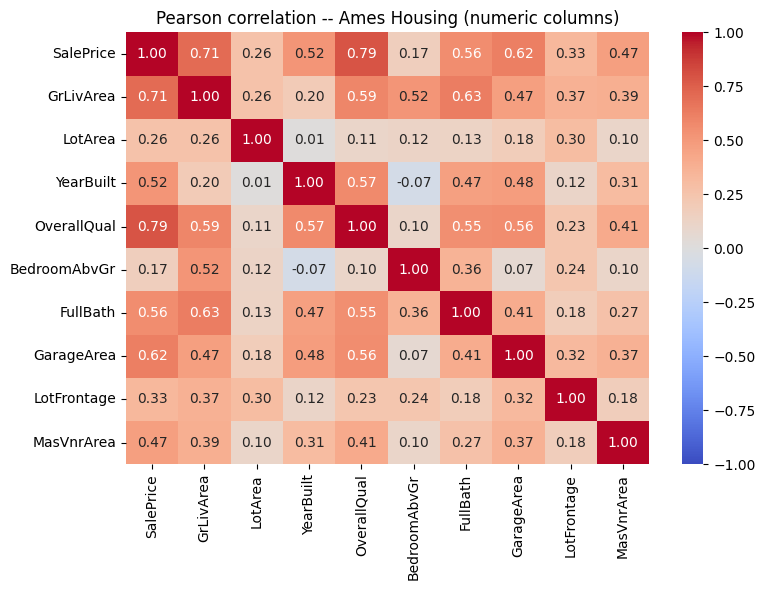

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation -- Ames Housing (numeric columns)")
fig.tight_layout()
plt.show()

> **Read it:** The diagonal is 1.0 (every variable is perfectly correlated with
> itself). Warm colors = positive correlation, cool = negative. GrLivArea and
> FullBath are also correlated with each other (0.63) -- bigger houses tend to
> have more bathrooms.

### 4b. GrLivArea vs SalePrice -- the quality story (worked)

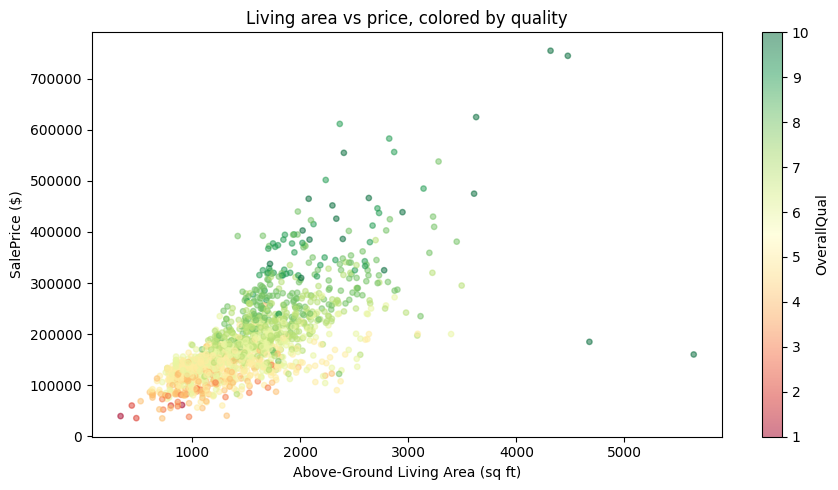

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(df["GrLivArea"], df["SalePrice"],
                     c=df["OverallQual"], cmap="RdYlGn",
                     alpha=0.5, s=15)
fig.colorbar(scatter, ax=ax, label="OverallQual")
ax.set_xlabel("Above-Ground Living Area (sq ft)")
ax.set_ylabel("SalePrice ($)")
ax.set_title("Living area vs price, colored by quality")
plt.tight_layout()
plt.show()

> **Read it:** There is a clear positive trend -- larger homes cost more. But
> the cloud fans out: at 2,000 sq ft you see prices from $100k to $350k. The
> color shows why: green dots (high quality) cluster at the top of the band,
> red dots (low quality) at the bottom. Quality and size together explain the
> spread. Median price for quality-9 homes ($345k) is 2.6x that of quality-5
> homes ($133k).

### 4c. YearBuilt vs SalePrice -- completion exercise

Newer homes tend to sell for more. Plot a scatter of YearBuilt vs SalePrice and
write a one-sentence read.

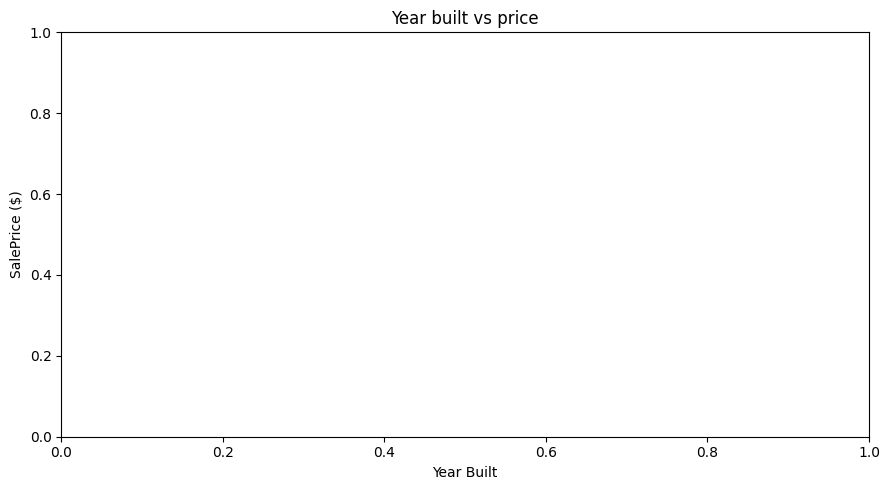

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
# TODO: uncomment and complete -- plot YearBuilt (x) vs SalePrice (y)
# ax.scatter(____, ____, alpha=0.3, s=15, color="#4c72b0")
ax.set_xlabel("Year Built")
ax.set_ylabel("SalePrice ($)")
ax.set_title("Year built vs price")
plt.tight_layout()
plt.show()

# TODO: write one sentence -- what trend do you see, and what is one limitation
#       of reading this as "newer = more expensive"?
# Read: ____

<details><summary>Expected Output</summary>

*A scatter plot with YearBuilt on x (1872-2010) and SalePrice on y ($35k-$755k).
Dots spread widely before 1960; a fan of higher prices opens up for homes built
after 2000, though the vertical spread remains large.*

*(Trend: homes built after 2000 cluster higher, but many older homes also sell
above median. Limitation: newer homes may also be larger or higher quality --
we cannot separate those effects from a scatter alone.)*
</details>

### 4d. SalePrice by HouseStyle -- grouped box plot (independent)

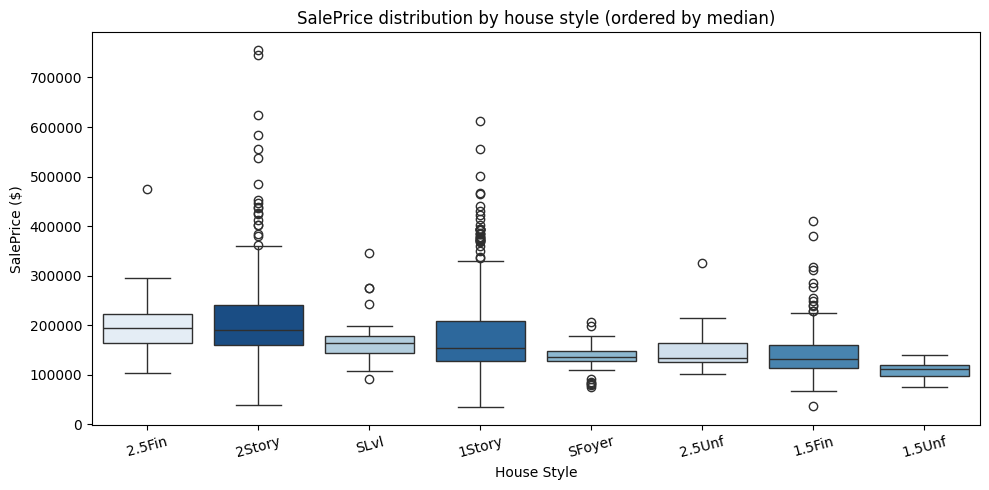

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
order = (df.groupby("HouseStyle")["SalePrice"]
           .median()
           .sort_values(ascending=False)
           .index)
sns.boxplot(data=df, x="HouseStyle", y="SalePrice", hue="HouseStyle",
            order=order, palette="Blues_r", legend=False, ax=ax)
ax.set_xlabel("House Style")
ax.set_ylabel("SalePrice ($)")
ax.set_title("SalePrice distribution by house style (ordered by median)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

> **Read it:** 2.5Fin (two-and-a-half-story finished) and 2Story homes have the
> highest medians ($194k and $190k). 1.5Unf (one-and-a-half-story unfinished)
> has the lowest median ($111k). The 1Story category dominates by count (726
> houses) and shows a wide interquartile range -- there is a lot of price
> variability even within a single style.

---

## Step 5: Synthesis -- Your Findings

Replace each `____` with your answer. There are no "wrong" answers here -- the
goal is to practice reading data critically.

In [18]:
# Run this cell to display your findings as formatted text.
# Fill in the three strings; keep them short (one sentence each).

finding_1 = "____"
# The strongest single predictor of SalePrice and why.
# (Hint: your heatmap and scatter have the answer.)

finding_2 = "____"
# One surprising or counter-intuitive result you noticed.
# (There is no single correct answer -- describe what caught your attention.)

finding_3 = "____"
# One limitation of this analysis or this dataset.
# (Think about what we did NOT look at, or what we cannot conclude.)

print("=== EDA Findings: Ames Housing ===")
print()
print(f"1. Strongest predictor:      {finding_1}")
print(f"2. Surprising result:         {finding_2}")
print(f"3. A key limitation:          {finding_3}")

=== EDA Findings: Ames Housing ===

1. Strongest predictor:      ____
2. Surprising result:         ____
3. A key limitation:          ____


<details><summary>Sample Answers</summary>

~~~text
=== EDA Findings: Ames Housing ===

1. Strongest predictor:      OverallQual (r = 0.79). Higher-rated materials
                              and workmanship command the biggest price premium.
2. Surprising result:         BedroomAbvGr has the weakest correlation (r = 0.17)
                              -- adding a bedroom does not reliably raise the price.
3. A key limitation:          We only looked at linear (Pearson) relationships.
                              Non-linear patterns -- like interaction effects
                              between quality and size -- are not captured here.
~~~
</details>

---

## Discussion

**Where this analysis could go next.** EDA tells us *what* the data shows, not
*why*. The patterns here -- OverallQual dominating, GrLivArea closely behind --
are correlational. Turning them into a price prediction requires regression or
tree-based models, which is Unit IV territory. An EDA like this one is the
mandatory first step: you would not trust a model built on data you haven't
looked at.

**A key limitation.** The Ames dataset covers 1,460 sales in a single Midwestern
city between 2006 and 2010 -- a period that includes the start of the U.S.
housing-market crash. Patterns here (what drives price, how strong the
correlations are) may not transfer to Puerto Rico, to major cities, or to
post-2010 markets. Any EDA finding is bounded by its data's geography, time, and
sampling method.

---

## Your Turn -- Exercises

### Exercise 1 -- Written: Imputation strategies

LotFrontage was imputed with the median. Under what missingness assumption is
that valid? If the missingness were MNAR (properties without street frontage
genuinely have no frontage, and it was left blank on purpose), what would you
do instead -- and why does it matter?

> **Hint:** Recall the taxonomy in the Appendix. Think about whether filling
> in 69 ft for a corner lot that has no frontage is accurate or misleading.

### Exercise 2 -- Code: LotArea vs SalePrice

Plot a scatter of LotArea (lot size in sq ft) vs SalePrice. Print the Pearson r.
Then write two sentences: (a) how the scatter differs from the GrLivArea scatter
in Step 4b, and (b) why a bigger lot does not guarantee a higher price.

In [19]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
Pearson r(LotArea, SalePrice) = 0.26
~~~
*(A scatter plot with LotArea on x and SalePrice on y. The cloud is wider and
noisier than the GrLivArea scatter, with several very large lots that did not
fetch high prices. The trend is positive but weak.)*
</details>

### Exercise 3 -- Open-ended: Explore a new variable

Load the full 81-column Ames dataset and find one column we did not explore that
looks interesting. Make one plot, print the Pearson r with SalePrice if it is
numeric, and write two sentences on what you found.

To get the full dataset, run this in a new cell first:

In [20]:
from sklearn.datasets import fetch_openml
raw = fetch_openml("house_prices", version=1, as_frame=True, parser="auto")
df_full = raw.frame
print(df_full.shape)   # (1460, 81)

(1460, 81)


In [21]:
# TODO: your code here

---

## Summary

| Step | Key commands | What you learned |
|------|-------------|-----------------|
| First look | `dtypes`, `isnull().sum()`, `describe()` | Structure, quality, headline numbers |
| Cleaning | `fillna(median())`, `fillna(0)` | Targeted impute beats `dropna()` for partial missingness |
| Univariate | `histplot`, `barplot`, `boxplot` | Shape, spread, skew per variable |
| Bivariate | `corr()`, `heatmap`, `scatter`, `boxplot` grouped | Linear relationships + visual context |
| Synthesis | written interpretation | EDA ends in sentences, not just plots |

---

## Appendix: MCAR, MAR, and MNAR (Optional)

<details><summary>Click to expand: missingness types</summary>

When data is missing, the *reason* matters for how you handle it.

| Type | Meaning | Example here | Best response |
|------|---------|--------------|---------------|
| **MCAR** -- Missing Completely at Random | Missingness has nothing to do with any variable | A surveyor randomly skipped a column | Safe to impute or drop |
| **MAR** -- Missing at Random | Missingness depends on other *observed* variables | LotFrontage missing more often for certain neighborhoods | Impute using other columns (or group-median) |
| **MNAR** -- Missing Not at Random | Missingness depends on the missing value itself | High-price homes underreport certain features | Imputing misleads -- flag the missingness with an indicator column |

For LotFrontage, MAR is plausible (certain lot shapes or neighborhoods may not
record frontage consistently). Median imputation is reasonable under MAR. Under
MNAR it would introduce bias -- the safer move is to add a binary
`LotFrontage_missing` column so any downstream analysis can account for the
pattern rather than hiding it.

</details>